In [1]:
import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
from nilearn.plotting import plot_surf, plot_surf_roi
from scipy.stats import norm

from compare_brain_maps.resampling import PermutationResampler, SubsampleResampler
from compare_brain_maps.smoothing import HeatKernelSmoother
from compare_brain_maps.utils import Surface

# simulation setting
n_resamples, n_repeats, n_vertices = 2000, 1000, 4002
surface_kwargs = dict(atlas="fsLR", density="4k", surface="sphere")

# initialize resamplers
sub_resampler = SubsampleResampler(n_subsamples=n_resamples, patch_size=4, reuse_patches=True, seed=0)
perm_resampler = PermutationResampler(n_permutations=n_resamples, reuse_spins=True, seed=0)

# simulate maps
rng = np.random.default_rng(0)
XY_data = rng.multivariate_normal(mean=[0, 0], cov=[[1, 0], [0, 1]], size=n_vertices * 2)  # under null
X = Surface({"left": XY_data[:n_vertices, 0], "right": XY_data[n_vertices:, 0]}, **surface_kwargs)
Y = Surface({"left": XY_data[:n_vertices, 1], "right": XY_data[n_vertices:, 1]}, **surface_kwargs)

# fit estimators
sub_resampler.fit(X, Y)
perm_resampler.fit(X, Y)
print(f"subsample={sub_resampler.params_.shape}\t\tpermutation={perm_resampler.params_.shape}")
print(f"subsample null={sub_resampler.null_}\t\tpermutation null={perm_resampler.null_}")

subsample=(2000,)		permutation=(2000,)
subsample null=True		permutation null=True


[Text(0.5, 0, 'correlation'), Text(0, 0.5, 'density')]

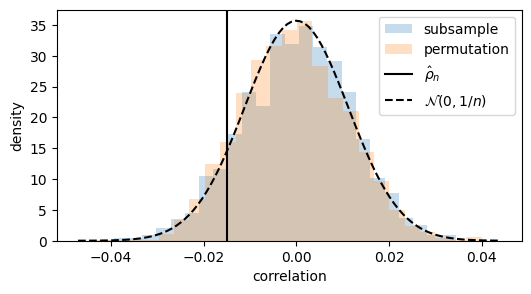

In [2]:
# plot resampled distributions vs iid bivariate normal CLT
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(sub_resampler.params_, alpha=0.25, density=True, bins=25, label="subsample")
ax.hist(perm_resampler.params_, alpha=0.25, density=True, bins=25, label="permutation")
ax.axvline(sub_resampler.param_, c="k", label=r"$\hat\rho_n$")
x = np.linspace(*ax.get_xlim(), 100)
ax.plot(x, norm.pdf(x, loc=0, scale=np.sqrt(1 / (2 * n_vertices))), "k--", label=r"$\mathcal{N}(0, 1/n)$")

ax.legend()
ax.set(xlabel="correlation", ylabel="density")

In [3]:
# !! 30s runtime !! FPR for iid bivariate normal
@delayed
def run_sim(rep):
    rng = np.random.default_rng(rep)
    XY_data = rng.multivariate_normal(mean=[0, 0], cov=[[1, 0], [0, 1]], size=n_vertices * 2)  # under null
    X = Surface({"left": XY_data[:n_vertices, 0], "right": XY_data[n_vertices:, 0]}, **surface_kwargs)
    Y = Surface({"left": XY_data[:n_vertices, 1], "right": XY_data[n_vertices:, 1]}, **surface_kwargs)
    sub_resampler.fit(X, Y)
    perm_resampler.fit(X, Y)
    return not sub_resampler.null_, not perm_resampler.null_


with Parallel(n_jobs=-1) as parallel:
    results = np.asarray(parallel(run_sim(rep) for rep in range(n_repeats)))
    sub_fpr, perm_fpr = results.mean(axis=0)

print(f"subsample FPR: {sub_fpr}\t\tpermutation FPR: {perm_fpr}")

subsample FPR: 0.054		permutation FPR: 0.047


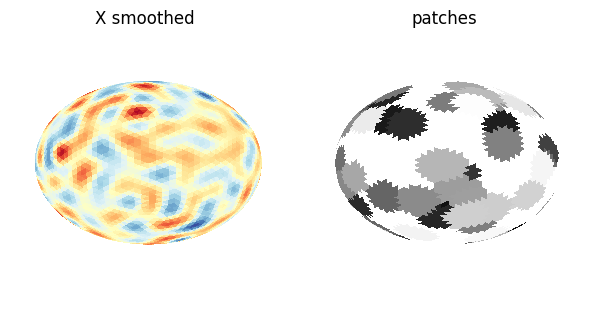

In [4]:
# plot smoothed maps and patches
sigma = 2
hk_smoother = HeatKernelSmoother(sigma=sigma, reuse_eigenpairs=True, seed=0)
sub_resampler = SubsampleResampler(n_subsamples=100, patch_size=3, seed=1)

# simulate maps
rng = np.random.default_rng(0)
X_data = rng.standard_normal(size=n_vertices * 2)
X = Surface({"left": X_data[:n_vertices], "right": X_data[n_vertices:]}, **surface_kwargs)
X_hk = hk_smoother.transform(Y)

# sample patches
sub_resampler.fit(X, X)
patch_labels = {
    hemi: np.where(patches.any(axis=1), patches.argmax(axis=1) + 1, 0)
    for hemi, patches in sub_resampler._patches.items()
}
X_patches = Surface(patch_labels, **surface_kwargs)

# plot smoothed maps and patches
fig, axs = plt.subplots(ncols=2, figsize=(6, 3), subplot_kw=dict(projection="3d"), layout="constrained")
_ = plot_surf(surf_map=X_hk, axes=axs[0], title="X smoothed", cmap="RdYlBu_r", colorbar=False)
_ = plot_surf_roi(roi_map=X_patches, axes=axs[1], title="patches", cmap="binary", colorbar=False, alpha=0.25)

In [5]:
# initialize resamplers
sub_resampler = SubsampleResampler(n_subsamples=n_resamples, patch_size=6, reuse_patches=True, seed=0)
perm_resampler = PermutationResampler(n_permutations=n_resamples, reuse_spins=True, seed=0)

# simulate maps
rng = np.random.default_rng(1)
XY_data = rng.multivariate_normal(mean=[0, 0], cov=[[1, 0], [0, 1]], size=n_vertices * 2)  # under null
X = Surface({"left": XY_data[:n_vertices, 0], "right": XY_data[n_vertices:, 0]}, **surface_kwargs)
Y = Surface({"left": XY_data[:n_vertices, 1], "right": XY_data[n_vertices:, 1]}, **surface_kwargs)
X_hk, Y_hk = hk_smoother.transform(X), hk_smoother.transform(Y)

# fit estimators
sub_resampler.fit(X_hk, Y_hk)
perm_resampler.fit(X_hk, Y_hk)
print(f"subsample={sub_resampler.params_.shape}\t\tpermutation={perm_resampler.params_.shape}")
print(f"subsample null={sub_resampler.null_}\t\tpermutation null={perm_resampler.null_}")

subsample=(2000,)		permutation=(2000,)
subsample null=True		permutation null=True


[Text(0.5, 0, 'correlation'), Text(0, 0.5, 'density')]

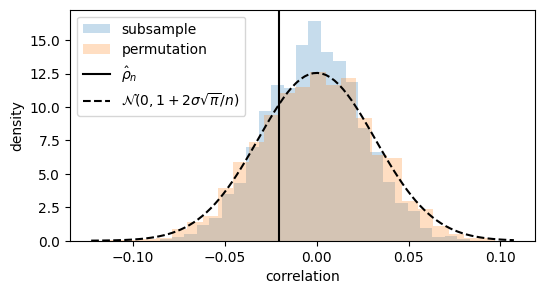

In [6]:
# plot resampled distributions vs smooth bivariate normal CLT
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(sub_resampler.params_, alpha=0.25, density=True, bins=25, label="subsample")
ax.hist(perm_resampler.params_, alpha=0.25, density=True, bins=25, label="permutation")
ax.axvline(sub_resampler.param_, c="k", label=r"$\hat\rho_n$")
x = np.linspace(*ax.get_xlim(), 100)
scale = np.sqrt((1 + 2 * sigma * np.sqrt(np.pi)) / (2 * n_vertices))  # bartlett formula
ax.plot(x, norm.pdf(x, loc=0, scale=scale), "k--", label=r"$\mathcal{N}(0, 1+2\sigma\sqrt{\pi}/n)$")

ax.legend()
ax.set(xlabel="correlation", ylabel="density")

In [7]:
# !! 60s runtime !! FPR for smooth bivariate normal
@delayed
def run_sim(rep):
    rng = np.random.default_rng(rep)
    XY_data = rng.multivariate_normal(mean=[0, 0], cov=[[1, 0], [0, 1]], size=n_vertices * 2)  # under null
    X = Surface({"left": XY_data[:n_vertices, 0], "right": XY_data[n_vertices:, 0]}, **surface_kwargs)
    Y = Surface({"left": XY_data[:n_vertices, 1], "right": XY_data[n_vertices:, 1]}, **surface_kwargs)
    X_hk, Y_hk = hk_smoother.transform(X), hk_smoother.transform(Y)
    sub_resampler.fit(X_hk, Y_hk)
    perm_resampler.fit(X_hk, Y_hk)
    return not sub_resampler.null_, not perm_resampler.null_


with Parallel(n_jobs=-1) as parallel:
    results = np.asarray(parallel(run_sim(rep) for rep in range(n_repeats)))
    sub_fpr, perm_fpr = results.mean(axis=0)

print(f"subsample FPR: {sub_fpr}\t\tpermutation FPR: {perm_fpr}")

subsample FPR: 0.091		permutation FPR: 0.045
